# Customer Churn Prediction & Retention Analytics System


# **Objective:**  
Analyze customer behavior, identify key factors associated with customer churn,
build machine learning models to predict churn, and generate actionable
customer retention insights.

# Import Libraries

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import seaborn for advanced statistical visualizations
import seaborn as sns

# Import warnings to control unnecessary warning messages
import warnings

# Ignore warning messages to keep the notebook output clean
warnings.filterwarnings("ignore")

# Display a confirmation message after importing libraries
print("Libraries imported successfully!")

Libraries imported successfully!


# Load Dataset

In [2]:
# Load the Telco Customer Churn CSV file into a pandas DataFrame
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display a confirmation message to verify that the dataset was loaded
print("Dataset loaded successfully!")

Dataset loaded successfully!


# Preview Dataset

In [3]:
# Display the first 5 rows of the dataset
# This helps us understand the structure and type of information available
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Check Dataset Shape

In [4]:
# Get the number of rows and columns in the dataset
rows, columns = df.shape

# Display the total number of records
print("Number of rows:", rows)

# Display the total number of features/columns
print("Number of columns:", columns)

Number of rows: 7043
Number of columns: 21


# Check Dataset Information

In [5]:
# Display basic information about the dataset
# This includes column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Statistical Summary

In [6]:
# Generate descriptive statistics for numerical columns
# This includes count, mean, standard deviation, minimum,
# maximum, and quartile values
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 3 — Data Cleaning & Data Quality Analysis

# Check Duplicate Rows

In [7]:
# Count the number of duplicate rows in the dataset
# Duplicate records can affect analysis and model performance
duplicate_count = df.duplicated().sum()

# Display the total number of duplicate rows
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# Check Missing Values

In [8]:
# Count missing values in each column
# Missing values need to be identified before machine learning
missing_values = df.isnull().sum()

# Display missing values for each column
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Missing Value Percentage

In [9]:
# Calculate the percentage of missing values in each column
# Percentage helps us understand the severity of missing data
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary table containing missing value counts and percentages
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

# Display only columns that contain missing values
missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage


# Check Data Types

In [10]:
# Display the data type of every column
# This helps identify numerical and categorical variables
print("Data types of all columns:")
print(df.dtypes)

Data types of all columns:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


#  Check Unique Values

In [11]:
# Count the number of unique values in each column
# This helps us understand categorical variables and possible data issues
unique_values = df.nunique()

# Display the number of unique values for every column
print("Number of unique values in each column:")
print(unique_values)

Number of unique values in each column:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


# Check Target Variable

In [12]:
# Display the unique values present in the Churn column
# This helps us understand the possible target categories
print("Unique Churn values:")
print(df["Churn"].unique())

# Count customers in each churn category
churn_counts = df["Churn"].value_counts()

# Display the number of customers in each category
print("\nCustomer count by Churn status:")
print(churn_counts)

Unique Churn values:
['No' 'Yes']

Customer count by Churn status:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# Churn Distribution

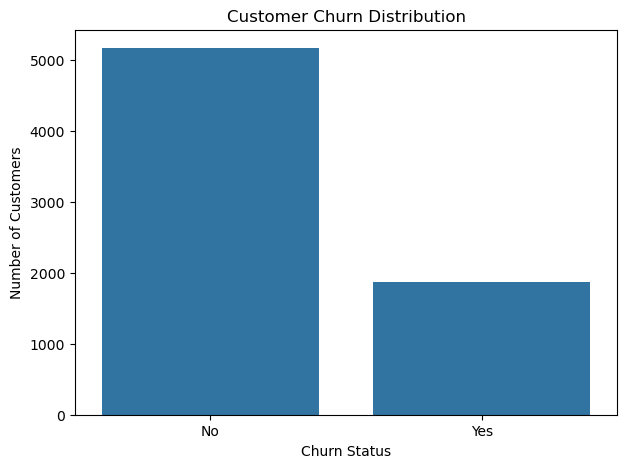

In [13]:
# Create a bar chart showing the distribution of customer churn
plt.figure(figsize=(7, 5))

# Count and plot the number of customers in each churn category
sns.countplot(data=df, x="Churn")

# Add a title to the chart
plt.title("Customer Churn Distribution")

# Add label to the x-axis
plt.xlabel("Churn Status")

# Add label to the y-axis
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

# Churn Percentage

In [14]:
# Calculate the percentage of customers in each churn category
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

# Display the churn percentage
print("Customer Churn Percentage:")
print(churn_percentage.round(2))

Customer Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


# 4 — Exploratory Data Analysis (EDA)

# Churn by Gender

In [15]:
# Create a cross-tabulation between gender and churn status
# This helps us compare churn behavior between male and female customers
gender_churn = pd.crosstab(df["gender"], df["Churn"])

# Display the churn count by gender
print("Churn count by gender:")
print(gender_churn)

Churn count by gender:
Churn     No  Yes
gender           
Female  2549  939
Male    2625  930


# Gender-wise Churn Percentage

In [16]:
# Calculate churn percentage within each gender group
# normalize="index" calculates percentages row-wise
gender_churn_percentage = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

# Display the percentage rounded to two decimal places
print("Churn percentage by gender:")
print(gender_churn_percentage.round(2))

Churn percentage by gender:
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


# Churn by Contract Type

In [17]:
# Create a cross-tabulation between contract type and churn status
# This helps us understand whether contract type is related to customer churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

# Display the churn count for each contract type
print("Churn count by contract type:")
print(contract_churn)

Churn count by contract type:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


# Contract-wise Churn Percentage

In [18]:
# Calculate the churn percentage for each contract type
# This allows us to compare churn rates fairly across contract groups
contract_churn_percentage = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

# Display the churn percentages rounded to two decimal places
print("Churn percentage by contract type:")
print(contract_churn_percentage.round(2))

Churn percentage by contract type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


# Contract vs Churn Visualization

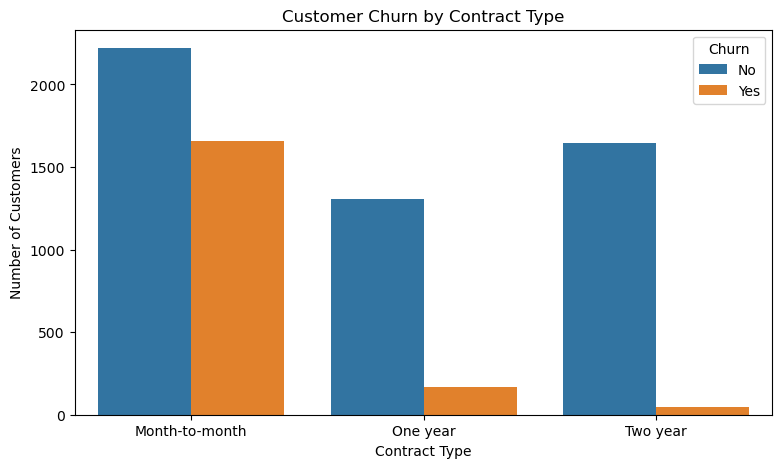

In [19]:
# Create a count plot to visualize churn across different contract types
plt.figure(figsize=(9, 5))

# Plot the number of customers by contract type and churn status
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

# Add a title to the chart
plt.title("Customer Churn by Contract Type")

# Add label to the x-axis
plt.xlabel("Contract Type")

# Add label to the y-axis
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

# Churn by Internet Service

In [20]:
# Create a cross-tabulation between internet service type and churn
# This helps identify whether internet service is associated with churn
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

# Display churn counts for each internet service type
print("Churn count by Internet Service:")
print(internet_churn)

Churn count by Internet Service:
Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


# Internet Service Churn Percentage

In [21]:
# Calculate churn percentage for each internet service category
internet_churn_percentage = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

# Display the percentages rounded to two decimal places
print("Churn percentage by Internet Service:")
print(internet_churn_percentage.round(2))

Churn percentage by Internet Service:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


# Monthly Charges vs Churn

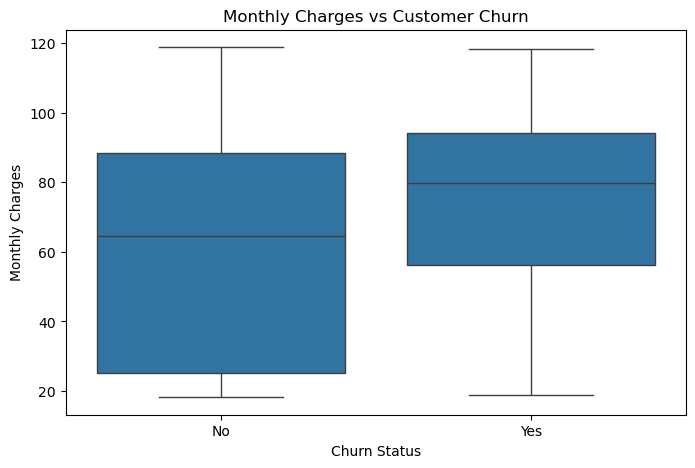

In [22]:
# Compare monthly charges for customers who churned and those who stayed
# A boxplot helps us understand the distribution and differences
# in monthly charges between the two churn groups
plt.figure(figsize=(8, 5))

# Create a boxplot for MonthlyCharges grouped by Churn
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

# Add a title to the chart
plt.title("Monthly Charges vs Customer Churn")

# Add label to the x-axis
plt.xlabel("Churn Status")

# Add label to the y-axis
plt.ylabel("Monthly Charges")

# Display the chart
plt.show()

# Tenure vs Churn

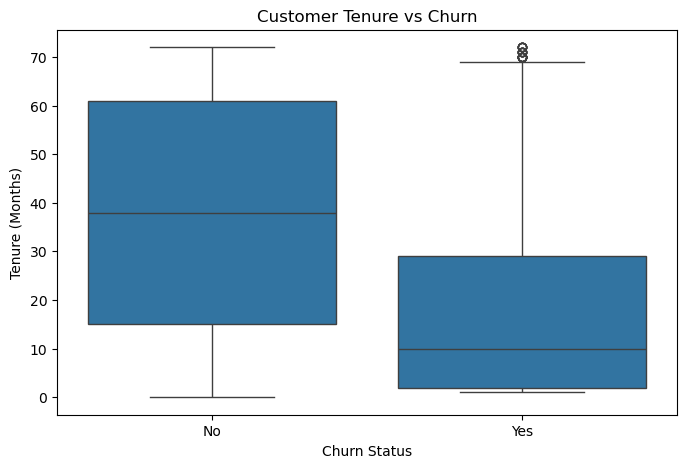

In [23]:
# Compare customer tenure between churned and non-churned customers
# This helps us understand whether customer loyalty is related to churn
plt.figure(figsize=(8, 5))

# Create a boxplot for tenure grouped by churn status
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

# Add a title to the chart
plt.title("Customer Tenure vs Churn")

# Add label to the x-axis
plt.xlabel("Churn Status")

# Add label to the y-axis
plt.ylabel("Tenure (Months)")

# Display the chart
plt.show()

# 5 — Deeper EDA: Customer Services & Churn Drivers

# Churn by Payment Method

In [24]:
# Create a cross-tabulation between payment method and churn status
# This helps us compare churn behavior across different payment methods
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

# Display the churn count for each payment method
print("Churn count by Payment Method:")
print(payment_churn)

Churn count by Payment Method:
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


# Payment Method Churn Percentage

In [25]:
# Calculate the percentage of churn within each payment method
# normalize="index" calculates the percentage separately for each payment group
payment_churn_percentage = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

# Display the churn percentages rounded to two decimal places
print("Churn percentage by Payment Method:")
print(payment_churn_percentage.round(2))

Churn percentage by Payment Method:
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


# Payment Method Visualization

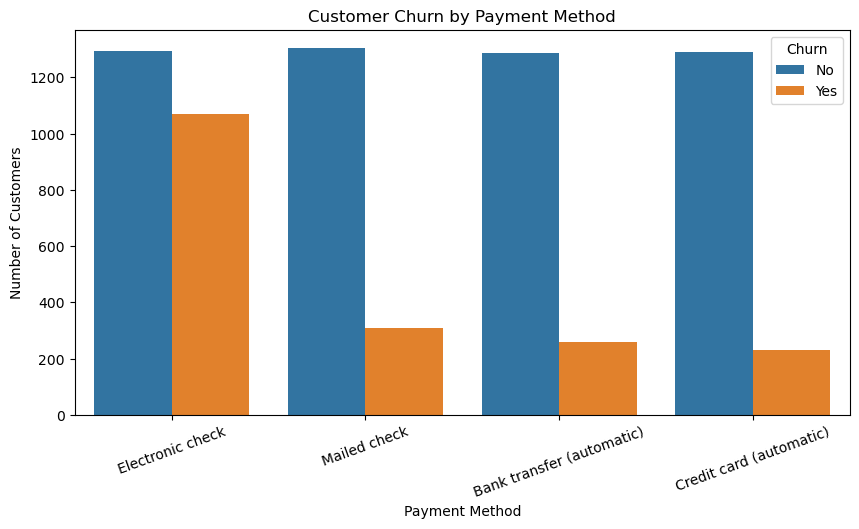

In [26]:
# Create a bar chart to visualize churn across payment methods
plt.figure(figsize=(10, 5))

# Plot payment method against churn status
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

# Add a title to the chart
plt.title("Customer Churn by Payment Method")

# Add label to the x-axis
plt.xlabel("Payment Method")

# Add label to the y-axis
plt.ylabel("Number of Customers")

# Rotate x-axis labels for better readability
plt.xticks(rotation=20)

# Display the chart
plt.show()

# Churn by Online Security

In [27]:
# Create a cross-tabulation between OnlineSecurity and Churn
# This helps us understand whether online security service is associated with churn
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"]
)

# Display the churn count for each Online Security category
print("Churn count by Online Security:")
print(security_churn)

Churn count by Online Security:
Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295


# Online Security Churn Percentage

In [28]:
# Calculate the churn percentage within each Online Security category
security_churn_percentage = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

# Display the churn percentages
print("Churn percentage by Online Security:")
print(security_churn_percentage.round(2))

Churn percentage by Online Security:
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


# Churn by Tech Support

In [29]:
# Create a cross-tabulation between TechSupport and Churn
# This helps us compare churn behavior based on technical support availability
support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)

# Display the churn count for each Tech Support category
print("Churn count by Tech Support:")
print(support_churn)

Churn count by Tech Support:
Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310


# Tech Support Churn Percentage

In [30]:
# Calculate the churn percentage within each Tech Support category
support_churn_percentage = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

# Display the churn percentages
print("Churn percentage by Tech Support:")
print(support_churn_percentage.round(2))

Churn percentage by Tech Support:
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


# Senior Citizen vs Churn

SeniorCitizen mein generally:

0 = Non-Senior Citizen
1 = Senior Citizen

In [31]:
# Create a cross-tabulation between SeniorCitizen and Churn
# This helps us compare churn behavior between the two age groups
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

# Display the churn count for each Senior Citizen category
print("Churn count by Senior Citizen status:")
print(senior_churn)

Churn count by Senior Citizen status:
Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476


# Senior Citizen Churn Percentage

In [32]:
# Calculate churn percentage for each Senior Citizen category
senior_churn_percentage = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

# Display the churn percentages
print("Churn percentage by Senior Citizen status:")
print(senior_churn_percentage.round(2))

Churn percentage by Senior Citizen status:
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


# Partner vs Churn

In [33]:
# Create a cross-tabulation between Partner status and Churn
# This helps us understand whether having a partner is associated with churn
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"]
)

# Display the churn count by Partner status
print("Churn count by Partner status:")
print(partner_churn)

Churn count by Partner status:
Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669


# Dependents vs Churn

In [34]:
# Create a cross-tabulation between Dependents status and Churn
# This helps us compare churn behavior based on whether customers have dependents
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"]
)

# Display the churn count by Dependents status
print("Churn count by Dependents status:")
print(dependents_churn)

Churn count by Dependents status:
Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326


# Create a Summary of Key Churn Factors

In [35]:
# Define important categorical features that may be related to customer churn
categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "Partner",
    "Dependents"
]

# Create an empty dictionary to store churn percentages
churn_summary = {}

# Calculate the churn percentage for each category of every selected feature
for feature in categorical_features:
    
    # Calculate churn percentage within each category
    percentage = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
    
    # Store the result in the dictionary
    churn_summary[feature] = percentage

# Display the calculated churn percentages
for feature, values in churn_summary.items():
    print(f"\n{feature}:")
    print(values.round(2))


Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

InternetService:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Yes, dtype: float64

PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Yes, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Yes, dtype: float64

TechSupport:
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Yes, dtype: float64

Partner:
Partner
No     32.96
Yes    19.66
Name: Yes, dtype: float64

Dependents:
Dependents
No     31.28
Yes    15.45
Name: Yes, dtype: float64


# 6 — Data Cleaning + Feature Engineering

# Create Clean Dataset

In [36]:
# Create a copy of the original dataset
# This keeps the original data unchanged for reference
df_clean = df.copy()

# Display the shape of the copied dataset
print("Clean dataset shape:", df_clean.shape)

Clean dataset shape: (7043, 21)


# Convert TotalCharges to Numeric

In [37]:
# Convert TotalCharges into numeric format
# errors="coerce" converts invalid or blank values into NaN
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Check the data type after conversion
print("Data type of TotalCharges:", df_clean["TotalCharges"].dtype)

Data type of TotalCharges: float64


# Check Missing Values Again

In [38]:
# Count missing values after converting TotalCharges to numeric
# This helps identify rows where TotalCharges could not be converted
missing_after_conversion = df_clean.isnull().sum()

# Display only columns that contain missing values
print("Missing values after conversion:")
print(missing_after_conversion[missing_after_conversion > 0])

Missing values after conversion:
TotalCharges    11
dtype: int64


# Handle Missing TotalCharges

In [39]:
# Calculate the median TotalCharges value
# Median is less affected by extreme values than the mean
median_total_charges = df_clean["TotalCharges"].median()

# Fill missing TotalCharges values with the median
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(
    median_total_charges
)

# Check whether TotalCharges still contains missing values
print(
    "Missing TotalCharges after treatment:",
    df_clean["TotalCharges"].isnull().sum()
)

Missing TotalCharges after treatment: 0


# Check Duplicate Rows

In [40]:
# Count duplicate rows in the cleaned dataset
duplicate_count_clean = df_clean.duplicated().sum()

# Display the number of duplicate rows
print("Duplicate rows:", duplicate_count_clean)

Duplicate rows: 0


# Remove Customer ID

In [42]:
# Remove customerID because it is a unique identifier
# It does not provide meaningful predictive information
df_clean = df_clean.drop(columns=["customerID"])

# Display the remaining column names
print("Columns after removing customerID:")
print(df_clean.columns.tolist())

Columns after removing customerID:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


# Convert Churn into Binary Target

Machine Learning model ke liye:

No → 0
Yes → 1

In [43]:
# Convert the target variable Churn from text into binary values
# "No" represents customers who stayed
# "Yes" represents customers who churned
df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Display the new Churn values
print("Unique Churn values:")
print(df_clean["Churn"].unique())

Unique Churn values:
[0 1]


# Create Tenure Groups

In [44]:
# Create customer tenure groups based on the number of months
# These groups help us analyze churn across different customer lifecycle stages
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

# Display the number of customers in each tenure group
print("Customers by Tenure Group:")
print(df_clean["TenureGroup"].value_counts().sort_index())

Customers by Tenure Group:
TenureGroup
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64


# Create Average Monthly Revenue Feature

In [45]:
# Create a safe tenure column
# Replace zero tenure with 1 temporarily to avoid division by zero
safe_tenure = df_clean["tenure"].replace(0, 1)

# Calculate average monthly revenue from TotalCharges and tenure
df_clean["AverageMonthlyRevenue"] = (
    df_clean["TotalCharges"] / safe_tenure
)

# Display the first few calculated values
df_clean[
    ["tenure", "TotalCharges", "AverageMonthlyRevenue"]
].head()

,tenure,TotalCharges,AverageMonthlyRevenue
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


# Check Final Dataset

In [46]:
# Display the first five rows of the cleaned dataset
# This helps verify that our cleaning and feature engineering were successful
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AverageMonthlyRevenue
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 Months,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48 Months,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 Months,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 Months,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 Months,75.825000


# Final Data Quality Check

In [48]:
# Count the total number of missing values in the cleaned dataset
total_missing = df_clean.isnull().sum().sum()

# Count the total number of duplicate rows
total_duplicates = df_clean.duplicated().sum()

# Display the data quality results before removing duplicates
print("Before removing duplicates:")
print("Total missing values:", total_missing)
print("Total duplicate rows:", total_duplicates)

Before removing duplicates:
Total missing values: 0
Total duplicate rows: 22


In [49]:
# Remove exact duplicate rows from the cleaned dataset
# keep="first" keeps the first occurrence and removes repeated records
df_clean = df_clean.drop_duplicates(keep="first")

# Reset the DataFrame index after removing duplicate rows
# drop=True prevents the old index from being added as a new column
df_clean = df_clean.reset_index(drop=True)

# Display the new dataset shape after removing duplicates
print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (7021, 22)


# Final Quality Check

In [50]:
# Recheck the number of missing values after data cleaning
final_missing = df_clean.isnull().sum().sum()

# Recheck the number of duplicate rows after removing duplicates
final_duplicates = df_clean.duplicated().sum()

# Display the final data quality results
print("Final Data Quality Check")
print("------------------------")
print("Total missing values:", final_missing)
print("Total duplicate rows:", final_duplicates)

Final Data Quality Check
------------------------
Total missing values: 0
Total duplicate rows: 0


# Save Updated Clean Dataset

In [51]:
# Save the final cleaned dataset
# This file will be used for feature engineering and machine learning
df_clean.to_csv(
    "../data/telco_customer_churn_cleaned.csv",
    index=False
)

# Display a confirmation message
print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


# Create ML Dataset

In [52]:
# Create a separate copy of the cleaned dataset for machine learning
# This keeps df_clean unchanged for analysis and reference
df_model = df_clean.copy()

# Display the shape of the ML dataset
print("ML dataset shape:", df_model.shape)

ML dataset shape: (7021, 22)


# Check Categorical Columns

In [53]:
# Select all categorical columns from the dataset
# These columns contain text values that machine learning models cannot directly use
categorical_columns = df_model.select_dtypes(
    include=["object", "category"]
).columns

# Display the categorical columns
print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


# Check Numerical Columns

In [54]:
# Select all numerical columns from the ML dataset
# Numerical columns can generally be used directly by machine learning algorithms
numerical_columns = df_model.select_dtypes(
    include=["int64", "float64"]
).columns

# Display the numerical columns
print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AverageMonthlyRevenue']


# Separate Features and Target

In [55]:
# Separate input features from the target variable
# X contains the information used to make predictions
# y contains the actual churn outcome
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Display the shape of the features dataset
print("Features shape:", X.shape)

# Display the shape of the target variable
print("Target shape:", y.shape)

Features shape: (7021, 21)
Target shape: (7021,)


# Check Target Distribution

In [56]:
# Count the number of customers in each target class
# This helps us understand whether the dataset is balanced or imbalanced
target_counts = y.value_counts()

# Display the target class counts
print("Target class distribution:")
print(target_counts)

Target class distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


# Target Distribution Percentage

In [57]:
# Calculate the percentage of customers in each churn class
# This gives us a clearer understanding of class imbalance
target_percentage = y.value_counts(normalize=True) * 100

# Display the percentages rounded to two decimal places
print("Target class percentage:")
print(target_percentage.round(2))

Target class percentage:
Churn
0    73.55
1    26.45
Name: proportion, dtype: float64


# Encode Categorical Variables

In [58]:
# Convert categorical variables into numerical dummy variables
# drop_first=True removes one category from each feature to reduce redundancy
X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

# Display the shape after encoding
print("Shape after categorical encoding:", X_encoded.shape)

Shape after categorical encoding: (7021, 34)


# Preview Encoded Dataset

In [59]:
# Display the first five rows of the encoded feature dataset
# This helps us verify that categorical variables were converted successfully
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AverageMonthlyRevenue,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 Months,TenureGroup_25-48 Months,TenureGroup_49-72 Months
0,0,1,29.85,29.85,29.850000,0,1,0,0,1,...,0,0,0,1,0,1,0,0,0,0
1,0,34,56.95,1889.50,55.573529,1,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0
2,0,2,53.85,108.15,54.075000,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,0
3,0,45,42.30,1840.75,40.905556,1,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0
4,0,2,70.70,151.65,75.825000,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0


# Check Data Types

In [60]:
# Check the data types of all encoded features
# Machine learning algorithms require appropriate numerical data types
print("Data types after encoding:")
print(X_encoded.dtypes.value_counts())

Data types after encoding:
int64      31
float64     3
Name: count, dtype: int64


# Check Final Feature Dataset

In [61]:
# Display the number of features after encoding
# One-hot encoding increases the number of columns
print("Number of features after encoding:", X_encoded.shape[1])

# Display the first five rows for a final verification
X_encoded.head()

Number of features after encoding: 34


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AverageMonthlyRevenue,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 Months,TenureGroup_25-48 Months,TenureGroup_49-72 Months
0,0,1,29.85,29.85,29.850000,0,1,0,0,1,...,0,0,0,1,0,1,0,0,0,0
1,0,34,56.95,1889.50,55.573529,1,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0
2,0,2,53.85,108.15,54.075000,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,0
3,0,45,42.30,1840.75,40.905556,1,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0
4,0,2,70.70,151.65,75.825000,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0


# 8 — Train/Test Split + Feature Scaling

# Train/Test Split

In [62]:
# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split the encoded features and target variable
# 80% data will be used for training and 20% for testing
# stratify=y keeps the churn class proportion similar in both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5616, 34)
Testing features: (1405, 34)
Training target: (5616,)
Testing target: (1405,)


# Check Target Distribution After Split

In [63]:
# Calculate the percentage of churn classes in the training dataset
# This verifies that stratified splitting maintained the class distribution
train_distribution = y_train.value_counts(normalize=True) * 100

# Calculate the percentage of churn classes in the testing dataset
test_distribution = y_test.value_counts(normalize=True) * 100

# Display the training distribution
print("Training target distribution:")
print(train_distribution.round(2))

# Display the testing distribution
print("\nTesting target distribution:")
print(test_distribution.round(2))

Training target distribution:
Churn
0    73.56
1    26.44
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.52
1    26.48
Name: proportion, dtype: float64


# Feature Scaling

In [64]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler only on the training data
# This prevents information from the test set leaking into the training process
X_train_scaled = scaler.fit_transform(X_train)

# Apply the already-fitted scaler to the test data
# We use transform instead of fit_transform for the test set
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the scaled datasets
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (5616, 34)
Scaled testing data shape: (1405, 34)


# Verify Scaling

In [65]:
# Calculate the mean of the first few scaled features
# StandardScaler should make the training features approximately centered around zero
scaled_means = X_train_scaled.mean(axis=0)

# Display the first 10 feature means
print("First 10 scaled feature means:")
print(scaled_means[:10])

First 10 scaled feature means:
[-1.13869028e-17  6.95866283e-17 -3.69441736e-16 -4.96595484e-17
  3.32117999e-17  4.68128227e-17 -1.01216914e-17  6.00975426e-17
  1.08175577e-16 -3.73237370e-17]


# Convert Scaled Data Back to DataFrame

In [66]:
# Convert the scaled training data back into a pandas DataFrame
# Keep the original feature names for easier interpretation
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

# Convert the scaled testing data back into a pandas DataFrame
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Display the first five rows of the scaled training data
X_train_scaled_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AverageMonthlyRevenue,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 Months,TenureGroup_25-48 Months,TenureGroup_49-72 Months
2624,-0.440315,-1.241331,0.193165,-0.946351,0.052956,1.000356,-0.973638,-0.653044,0.322812,-0.322812,...,-0.796231,-0.51631,-0.56419,-1.222657,1.905215,-0.716477,-0.540301,-0.414672,-0.543876,-0.681754
2645,-0.440315,-0.711078,0.647355,-0.435346,0.322305,-0.999644,-0.973638,-0.653044,0.322812,-0.322812,...,-0.796231,-0.51631,-0.56419,0.817891,1.905215,-0.716477,-0.540301,2.411542,-0.543876,-0.681754
1416,-0.440315,1.409933,0.820380,1.794547,0.457484,1.000356,1.027076,1.531290,0.322812,-0.322812,...,1.255918,-0.51631,-0.56419,0.817891,-0.524875,-0.716477,-0.540301,-0.414672,-0.543876,1.466804
5760,-0.440315,-1.118965,0.023467,-0.858746,0.014252,1.000356,-0.973638,-0.653044,0.322812,-0.322812,...,1.255918,-0.51631,-0.56419,0.817891,-0.524875,-0.716477,-0.540301,-0.414672,-0.543876,-0.681754
2420,-0.440315,-0.262403,-1.483847,-0.783389,-0.774796,1.000356,-0.973638,-0.653044,0.322812,-0.322812,...,-0.796231,-0.51631,-0.56419,0.817891,-0.524875,1.395719,-0.540301,-0.414672,1.838656,-0.681754


# Final ML Preparation Check

In [67]:
# Verify that the training and testing datasets contain no missing values
print("Missing values in training data:", X_train_scaled_df.isnull().sum().sum())
print("Missing values in testing data:", X_test_scaled_df.isnull().sum().sum())

# Display the final number of training features
print("Number of features:", X_train_scaled_df.shape[1])

# Display the number of training records
print("Training records:", X_train_scaled_df.shape[0])

# Display the number of testing records
print("Testing records:", X_test_scaled_df.shape[0])

Missing values in training data: 0
Missing values in testing data: 0
Number of features: 34
Training records: 5616
Testing records: 1405


# 9 —  Machine Learning Model

# Import Logistic Regression

In [68]:
# Import Logistic Regression for binary classification
# Our target variable has two classes:
# 0 = Customer stayed
# 1 = Customer churned
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics to measure model performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Display a confirmation message
print("Logistic Regression and evaluation metrics imported successfully!")

Logistic Regression and evaluation metrics imported successfully!


# Create Logistic Regression Model

In [69]:
# Create a Logistic Regression model
# max_iter is increased to give the model enough iterations to converge
# random_state ensures reproducible results
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Display the model configuration
print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


# Train the Model

In [70]:
# Train the Logistic Regression model using the training data
# The model learns the relationship between customer features and churn
logistic_model.fit(
    X_train_scaled,
    y_train
)

# Display a confirmation message after training
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# Make Predictions

In [71]:
# Predict the churn class for customers in the test dataset
# The model returns either 0 (No Churn) or 1 (Churn)
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Generate churn probabilities for the test customers
# [:, 1] selects the probability of the positive class, which is Churn = 1
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 predicted classes
print("First 10 predicted churn values:")
print(y_pred_logistic[:10])

# Display the first 10 predicted churn probabilities
print("\nFirst 10 churn probabilities:")
print(y_prob_logistic[:10])

First 10 predicted churn values:
[1 1 0 0 0 0 0 1 0 0]

First 10 churn probabilities:
[0.78751415 0.5524809  0.29867602 0.04474359 0.01107029 0.2858671
 0.16398428 0.83037428 0.01181401 0.01219365]


# Calculate Accuracy

In [72]:
# Calculate the percentage of test predictions that are correct
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

# Display the Logistic Regression accuracy
print("Logistic Regression Accuracy:", round(accuracy_logistic, 4))

Logistic Regression Accuracy: 0.8021


#  Calculate Precision, Recall and F1-Score

In [73]:
# Calculate precision
# Precision tells us how many customers predicted as churn actually churned
precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

# Calculate recall
# Recall tells us how many actual churned customers were correctly identified
recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

# Calculate F1-score
# F1-score balances precision and recall
f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

# Display all three evaluation metrics
print("Precision:", round(precision_logistic, 4))
print("Recall:", round(recall_logistic, 4))
print("F1-Score:", round(f1_logistic, 4))

Precision: 0.6691
Recall: 0.5
F1-Score: 0.5723


# ROC-AUC Score

In [74]:
# Calculate ROC-AUC using the predicted churn probabilities
# ROC-AUC measures how well the model separates churned and non-churned customers
roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

# Display the ROC-AUC score
print("ROC-AUC Score:", round(roc_auc_logistic, 4))

ROC-AUC Score: 0.8406


# Classification Report

In [75]:
# Generate a detailed classification report
# It contains precision, recall, F1-score and support for both classes
print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Stayed", "Churned"]
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.91      0.87      1033
     Churned       0.67      0.50      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



# Confusion Matrix

In [76]:
# Calculate the confusion matrix
# It shows correct and incorrect predictions for both classes
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Display the raw confusion matrix
print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[941  92]
 [186 186]]


# Visualize Confusion Matrix

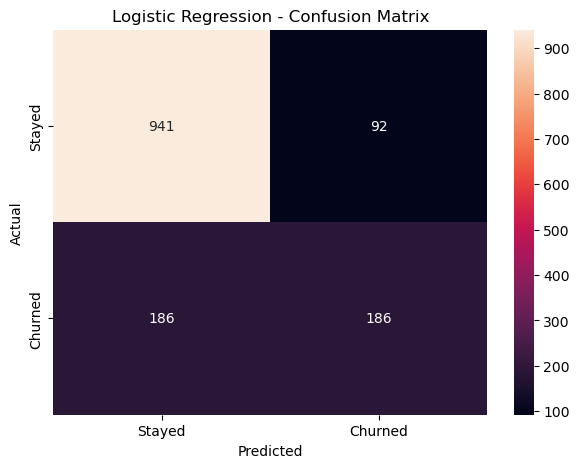

In [77]:
# Create a figure for the confusion matrix
plt.figure(figsize=(7, 5))

# Create a heatmap to visualize the confusion matrix
# annot=True displays the numerical values inside each cell
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

# Add a title to the visualization
plt.title("Logistic Regression - Confusion Matrix")

# Label the x-axis
plt.xlabel("Predicted")

# Label the y-axis
plt.ylabel("Actual")

# Display the confusion matrix
plt.show()

# 10. Decision Tree Classifier

# Import Decision Tree

In [78]:
# Import DecisionTreeClassifier for classification
# Decision Tree creates a series of decision rules to classify customers
from sklearn.tree import DecisionTreeClassifier

# Display a confirmation message
print("Decision Tree classifier imported successfully!")

Decision Tree classifier imported successfully!


# Create Decision Tree Model

In [79]:
# Create a Decision Tree classifier
# max_depth limits the depth of the tree to reduce overfitting
# random_state ensures reproducible results
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Display the model configuration
print(decision_tree_model)

DecisionTreeClassifier(max_depth=5, random_state=42)


# Train Decision Tree

In [80]:
# Train the Decision Tree using the training dataset
# The model learns decision rules from customer features
decision_tree_model.fit(
    X_train,
    y_train
)

# Display a confirmation message
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


# Make Predictions

In [81]:
# Predict the churn class for customers in the test dataset
y_pred_tree = decision_tree_model.predict(
    X_test
)

# Generate churn probabilities for ROC-AUC calculation
# [:, 1] selects the probability of the churn class
y_prob_tree = decision_tree_model.predict_proba(
    X_test
)[:, 1]

# Display the first 10 predictions
print("First 10 predicted churn values:")
print(y_pred_tree[:10])

First 10 predicted churn values:
[1 0 1 0 0 0 0 1 0 0]


# Calculate Accuracy

In [82]:
# Calculate the accuracy of the Decision Tree model
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

# Display the accuracy score
print("Decision Tree Accuracy:", round(accuracy_tree, 4))

Decision Tree Accuracy: 0.7836


# Calculate Precision, Recall and F1

In [83]:
# Calculate precision for the Decision Tree
precision_tree = precision_score(
    y_test,
    y_pred_tree
)

# Calculate recall for the Decision Tree
recall_tree = recall_score(
    y_test,
    y_pred_tree
)

# Calculate F1-score for the Decision Tree
f1_tree = f1_score(
    y_test,
    y_pred_tree
)

# Display the evaluation metrics
print("Precision:", round(precision_tree, 4))
print("Recall:", round(recall_tree, 4))
print("F1-Score:", round(f1_tree, 4))

Precision: 0.6478
Recall: 0.4005
F1-Score: 0.495


# ROC-AUC

In [84]:
# Calculate ROC-AUC using the predicted churn probabilities
roc_auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

# Display the ROC-AUC score
print("ROC-AUC Score:", round(roc_auc_tree, 4))

ROC-AUC Score: 0.8217


# Classification Report

In [85]:
# Generate a detailed classification report
# This provides precision, recall, F1-score and support for both classes
print("Decision Tree Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Stayed", "Churned"]
    )
)

Decision Tree Classification Report:
              precision    recall  f1-score   support

      Stayed       0.81      0.92      0.86      1033
     Churned       0.65      0.40      0.50       372

    accuracy                           0.78      1405
   macro avg       0.73      0.66      0.68      1405
weighted avg       0.77      0.78      0.77      1405



# Confusion Matrix

In [86]:
# Calculate the confusion matrix for the Decision Tree model
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

# Display the confusion matrix
print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[952  81]
 [223 149]]


# Visualize Confusion Matrix

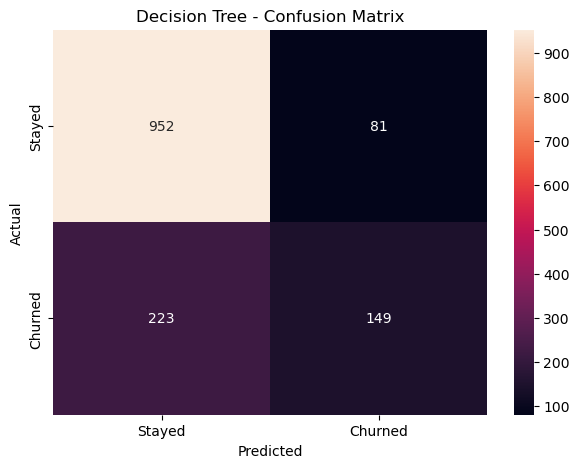

In [87]:
# Create a figure for the Decision Tree confusion matrix
plt.figure(figsize=(7, 5))

# Display the confusion matrix using a heatmap
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

# Add a title to the chart
plt.title("Decision Tree - Confusion Matrix")

# Label the x-axis
plt.xlabel("Predicted")

# Label the y-axis
plt.ylabel("Actual")

# Display the chart
plt.show()

# Feature Importance

In [88]:
# Extract feature importance values from the trained Decision Tree
feature_importance_tree = pd.Series(
    decision_tree_model.feature_importances_,
    index=X_train.columns
)

# Sort features from highest to lowest importance
feature_importance_tree = feature_importance_tree.sort_values(
    ascending=False
)

# Display the top 15 most important features
print("Top 15 important features:")
print(feature_importance_tree.head(15))

Top 15 important features:
tenure                                   0.431725
InternetService_Fiber optic              0.353494
TotalCharges                             0.041991
AverageMonthlyRevenue                    0.033689
Contract_One year                        0.025549
StreamingMovies_No internet service      0.022656
PaymentMethod_Electronic check           0.018874
OnlineSecurity_No internet service       0.018535
Contract_Two year                        0.017583
OnlineSecurity_Yes                       0.007992
MultipleLines_No phone service           0.007197
MultipleLines_Yes                        0.006542
MonthlyCharges                           0.005494
TechSupport_Yes                          0.004753
PaymentMethod_Credit card (automatic)    0.002396
dtype: float64


# Visualize Feature Importance

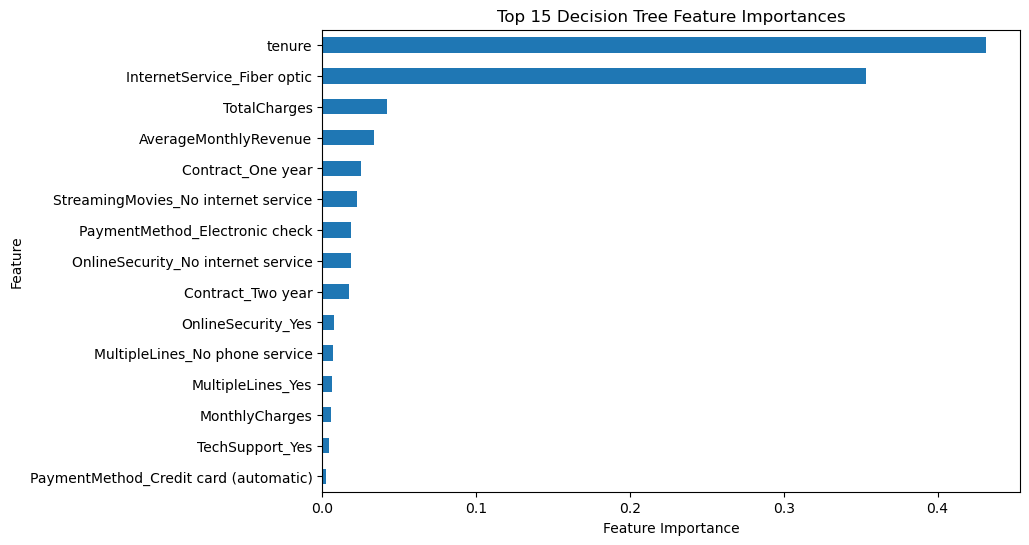

In [89]:
# Select the top 15 features for visualization
top_features_tree = feature_importance_tree.head(15)

# Create a horizontal bar chart
plt.figure(figsize=(9, 6))

# Plot the feature importance values
top_features_tree.sort_values().plot(kind="barh")

# Add a title to the chart
plt.title("Top 15 Decision Tree Feature Importances")

# Label the x-axis
plt.xlabel("Feature Importance")

# Label the y-axis
plt.ylabel("Feature")

# Display the chart
plt.show()

# 11 — Random Forest Classifier

# Import Random Forest

In [90]:
# Import RandomForestClassifier for classification
# Random Forest combines multiple decision trees to improve prediction performance
from sklearn.ensemble import RandomForestClassifier

# Display a confirmation message
print("Random Forest classifier imported successfully!")

Random Forest classifier imported successfully!


# Create Random Forest Model

In [91]:
# Create a Random Forest classifier
# n_estimators specifies the number of decision trees
# max_depth limits the depth of each tree to help control overfitting
# random_state ensures reproducible results
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Display the model configuration
print(random_forest_model)

RandomForestClassifier(max_depth=8, n_estimators=200, n_jobs=-1,
                       random_state=42)


# Train Random Forest

In [92]:
# Train the Random Forest model using the training dataset
# Random Forest does not require feature scaling
random_forest_model.fit(
    X_train,
    y_train
)

# Display a confirmation message after training
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# Make Predictions

In [93]:
# Predict the churn class for customers in the test dataset
y_pred_rf = random_forest_model.predict(
    X_test
)

# Generate churn probabilities for the test customers
# [:, 1] selects the probability of the churn class
y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Display the first 10 predicted churn values
print("First 10 predicted churn values:")
print(y_pred_rf[:10])

# Display the first 10 churn probabilities
print("\nFirst 10 churn probabilities:")
print(y_prob_rf[:10])

First 10 predicted churn values:
[1 0 0 0 0 0 0 1 0 0]

First 10 churn probabilities:
[0.63580883 0.40571751 0.4844566  0.12133712 0.08718617 0.27633641
 0.07243206 0.79404135 0.01045212 0.05092632]


# Calculate Accuracy

In [94]:
# Calculate the accuracy of the Random Forest model
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

# Display the accuracy score
print("Random Forest Accuracy:", round(accuracy_rf, 4))

Random Forest Accuracy: 0.7893


# Precision, Recall & F1-Score

In [95]:
# Calculate precision for the Random Forest model
precision_rf = precision_score(
    y_test,
    y_pred_rf
)

# Calculate recall for the Random Forest model
recall_rf = recall_score(
    y_test,
    y_pred_rf
)

# Calculate F1-score for the Random Forest model
f1_rf = f1_score(
    y_test,
    y_pred_rf
)

# Display the evaluation metrics
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-Score:", round(f1_rf, 4))

Precision: 0.6473
Recall: 0.4489
F1-Score: 0.5302


# ROC-AUC Score

In [96]:
# Calculate the ROC-AUC score using churn probabilities
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

# Display the ROC-AUC score
print("ROC-AUC Score:", round(roc_auc_rf, 4))

ROC-AUC Score: 0.8374


# Classification Report

In [97]:
# Generate a detailed classification report for Random Forest
# The report includes precision, recall, F1-score and support
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Stayed", "Churned"]
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.91      0.86      1033
     Churned       0.65      0.45      0.53       372

    accuracy                           0.79      1405
   macro avg       0.73      0.68      0.70      1405
weighted avg       0.78      0.79      0.78      1405



# Confusion Matrix

In [98]:
# Calculate the confusion matrix for Random Forest
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

# Display the confusion matrix
print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[942  91]
 [205 167]]


# Visualize Confusion Matrix

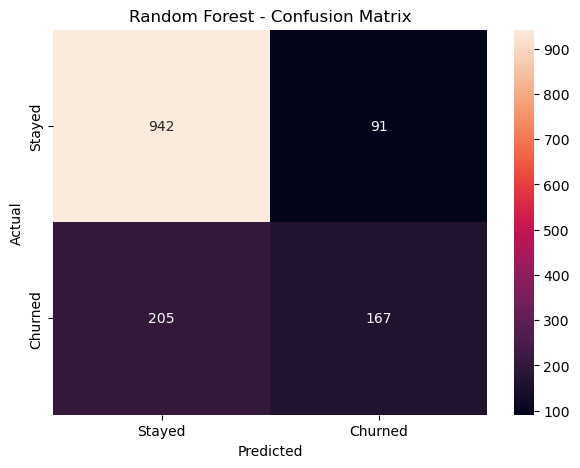

In [99]:
# Create a figure for the Random Forest confusion matrix
plt.figure(figsize=(7, 5))

# Display the confusion matrix as a heatmap
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

# Add a title to the chart
plt.title("Random Forest - Confusion Matrix")

# Label the x-axis
plt.xlabel("Predicted")

# Label the y-axis
plt.ylabel("Actual")

# Display the chart
plt.show()

# Random Forest Feature Importance

In [100]:
# Extract feature importance values from the trained Random Forest model
feature_importance_rf = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train.columns
)

# Sort features from highest to lowest importance
feature_importance_rf = feature_importance_rf.sort_values(
    ascending=False
)

# Display the top 15 most important features
print("Top 15 Random Forest features:")
print(feature_importance_rf.head(15))

Top 15 Random Forest features:
tenure                                 0.173729
TotalCharges                           0.126905
InternetService_Fiber optic            0.083273
MonthlyCharges                         0.078827
AverageMonthlyRevenue                  0.074466
Contract_Two year                      0.061916
PaymentMethod_Electronic check         0.053641
TenureGroup_49-72 Months               0.045553
Contract_One year                      0.028009
OnlineSecurity_Yes                     0.026952
TechSupport_Yes                        0.023184
InternetService_No                     0.016494
TechSupport_No internet service        0.016058
StreamingMovies_No internet service    0.015766
PaperlessBilling_Yes                   0.015170
dtype: float64


# Visualize Top Features

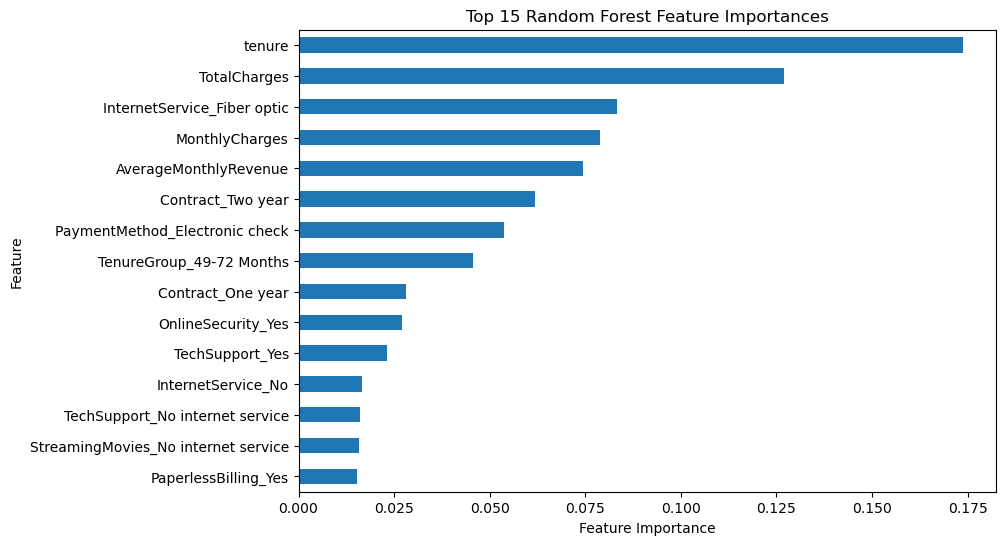

In [101]:
# Select the top 15 features based on Random Forest importance
top_features_rf = feature_importance_rf.head(15)

# Create a horizontal bar chart
plt.figure(figsize=(9, 6))

# Plot the feature importance values
top_features_rf.sort_values().plot(kind="barh")

# Add a title to the chart
plt.title("Top 15 Random Forest Feature Importances")

# Label the x-axis
plt.xlabel("Feature Importance")

# Label the y-axis
plt.ylabel("Feature")

# Display the chart
plt.show()

# Compare All 3 Models

In [103]:
# Create a DataFrame to compare the performance of all three models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    "F1-Score": [
        f1_logistic,
        f1_tree,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_tree,
        roc_auc_rf
    ]
})

# Round all metric values to four decimal places
model_comparison = model_comparison.round(4)

# Display the model comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8021,0.6691,0.5000,0.5723,0.8406
1,Decision Tree,0.7836,0.6478,0.4005,0.4950,0.8217
2,Random Forest,0.7893,0.6473,0.4489,0.5302,0.8374


# Visual Model Comparison

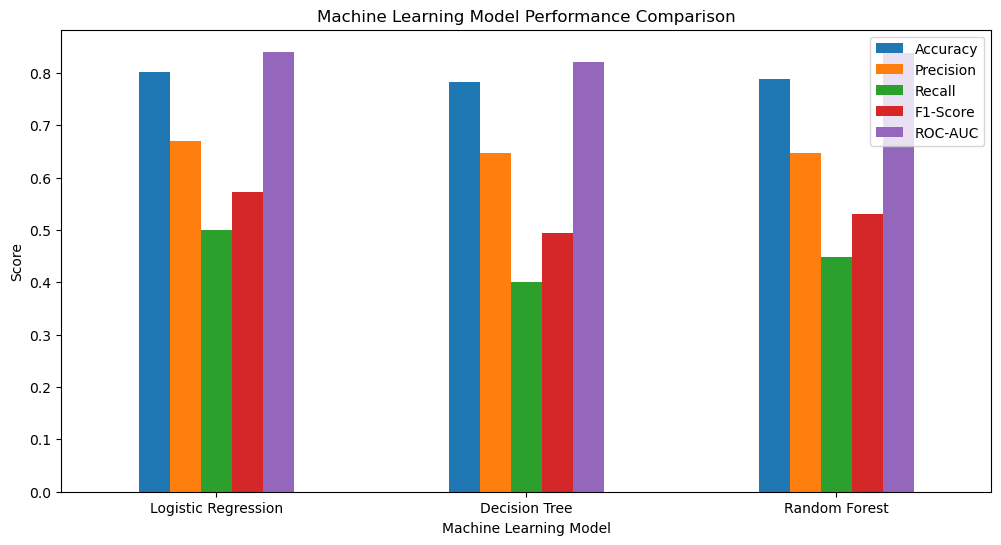

In [104]:
# Set the model name as the index for easier visualization
comparison_plot = model_comparison.set_index("Model")

# Select the main evaluation metrics for comparison
comparison_plot[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

# Add a title to the comparison chart
plt.title("Machine Learning Model Performance Comparison")

# Label the x-axis
plt.xlabel("Machine Learning Model")

# Label the y-axis
plt.ylabel("Score")

# Rotate model names for better readability
plt.xticks(rotation=0)

# Add a legend
plt.legend()

# Display the chart
plt.show()

# 11. Hyperparameter Tuning

# Import GridSearchCV

In [105]:
# Import GridSearchCV for hyperparameter tuning
# GridSearchCV tests multiple parameter combinations
# and identifies the combination that performs best
from sklearn.model_selection import GridSearchCV

# Display a confirmation message
print("GridSearchCV imported successfully!")

GridSearchCV imported successfully!


# Parameters define

In [106]:
# Define different hyperparameter values for Logistic Regression
# C controls the strength of regularization
# Different C values allow us to find a better model configuration
param_grid_logistic = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# Display the parameter combinations
print("Hyperparameter grid:")
print(param_grid_logistic)

Hyperparameter grid:
{'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}


# Grid Search run

In [107]:
# Create GridSearchCV for Logistic Regression
# scoring="roc_auc" means we will select the model
# with the highest ROC-AUC score
# cv=5 means 5-fold cross-validation will be used
grid_search_logistic = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid_logistic,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Train and evaluate all parameter combinations
grid_search_logistic.fit(
    X_train_scaled,
    y_train
)

# Display a confirmation message
print("Logistic Regression hyperparameter tuning completed!")

Logistic Regression hyperparameter tuning completed!


# Best parameters

In [108]:
# Get the best hyperparameter combination found by GridSearchCV
best_params_logistic = grid_search_logistic.best_params_

# Get the best cross-validation ROC-AUC score
best_cv_score_logistic = grid_search_logistic.best_score_

# Display the best parameters
print("Best Logistic Regression parameters:")
print(best_params_logistic)

# Display the best cross-validation ROC-AUC score
print("\nBest Cross-Validation ROC-AUC:",
      round(best_cv_score_logistic, 4))

Best Logistic Regression parameters:
{'C': 10, 'solver': 'liblinear'}

Best Cross-Validation ROC-AUC: 0.8474


# 12 — Tuned Logistic Regression Evaluation

# Best model

In [109]:
# Get the best Logistic Regression model found during hyperparameter tuning
# This model uses the best parameters identified by GridSearchCV
tuned_logistic_model = grid_search_logistic.best_estimator_

# Display the tuned model configuration
print("Tuned Logistic Regression model:")
print(tuned_logistic_model)

Tuned Logistic Regression model:
LogisticRegression(C=10, max_iter=1000, random_state=42, solver='liblinear')


# Test data prediction

In [110]:
# Predict the churn class for the unseen test dataset
y_pred_tuned = tuned_logistic_model.predict(X_test_scaled)

# Generate churn probabilities for the test customers
# [:, 1] selects the probability of the customer being in the churn class
y_prob_tuned = tuned_logistic_model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 predictions
print("First 10 predicted churn values:")
print(y_pred_tuned[:10])

# Display the first 10 churn probabilities
print("\nFirst 10 churn probabilities:")
print(y_prob_tuned[:10])

First 10 predicted churn values:
[1 1 0 0 0 0 0 1 0 0]

First 10 churn probabilities:
[0.78661331 0.54407266 0.29374011 0.04326566 0.01104693 0.29819388
 0.16330588 0.83795238 0.01121206 0.0125273 ]


# Accuracy, Precision, Recall, F1

In [111]:
# Calculate accuracy of the tuned Logistic Regression model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

# Calculate precision
precision_tuned = precision_score(y_test, y_pred_tuned)

# Calculate recall
recall_tuned = recall_score(y_test, y_pred_tuned)

# Calculate F1-score
f1_tuned = f1_score(y_test, y_pred_tuned)

# Display all evaluation metrics
print("Tuned Logistic Regression Performance")
print("--------------------------------------")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1-Score :", round(f1_tuned, 4))

Tuned Logistic Regression Performance
--------------------------------------
Accuracy : 0.8028
Precision: 0.6678
Recall   : 0.5081
F1-Score : 0.5771


# ROC-AUC

In [112]:
# Calculate ROC-AUC using the predicted churn probabilities
# ROC-AUC measures how well the model separates churned and non-churned customers
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

# Display the ROC-AUC score
print("Tuned Logistic Regression ROC-AUC:",
      round(roc_auc_tuned, 4))

Tuned Logistic Regression ROC-AUC: 0.8405


# Classification Report

In [113]:
# Generate a detailed classification report
# It shows precision, recall and F1-score for both customer classes
print("Tuned Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Stayed", "Churned"]
    )
)

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1033
     Churned       0.67      0.51      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



# Confusion Matrix

In [114]:
# Calculate the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Display the confusion matrix
print("Tuned Logistic Regression Confusion Matrix:")
print(cm_tuned)

Tuned Logistic Regression Confusion Matrix:
[[939  94]
 [183 189]]


# Confusion Matrix Visualization

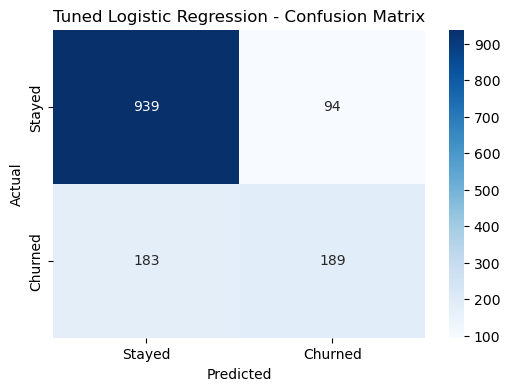

In [115]:
# Create a figure for the confusion matrix
plt.figure(figsize=(6, 4))

# Create a heatmap to visualize the confusion matrix
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

# Add chart title and axis labels
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the visualization
plt.show()

# 13 — Before vs After Tuning

# Comparison table

In [116]:
# Create a comparison table between the original and tuned Logistic Regression models
# This helps us understand whether hyperparameter tuning improved the model

logistic_tuning_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    
    "Original Logistic Regression": [
        accuracy_logistic,
        precision_logistic,
        recall_logistic,
        f1_logistic,
        roc_auc_logistic
    ],
    
    "Tuned Logistic Regression": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned,
        roc_auc_tuned
    ]
})

# Round the values to 4 decimal places for better readability
logistic_tuning_comparison = logistic_tuning_comparison.round(4)

# Display the comparison table
logistic_tuning_comparison

,Metric,Original Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.8021,0.8028
1,Precision,0.6691,0.6678
2,Recall,0.5000,0.5081
3,F1-Score,0.5723,0.5771
4,ROC-AUC,0.8406,0.8405


# Improvement calculate

In [117]:
# Calculate the improvement obtained after hyperparameter tuning
# Positive values indicate improvement in the corresponding metric

improvement = {
    "Accuracy": accuracy_tuned - accuracy_logistic,
    "Precision": precision_tuned - precision_logistic,
    "Recall": recall_tuned - recall_logistic,
    "F1-Score": f1_tuned - f1_logistic,
    "ROC-AUC": roc_auc_tuned - roc_auc_logistic
}

# Convert the improvement results into a DataFrame
improvement_df = pd.DataFrame(
    list(improvement.items()),
    columns=["Metric", "Improvement"]
)

# Round the improvement values
improvement_df["Improvement"] = improvement_df["Improvement"].round(4)

# Display the improvement results
improvement_df

,Metric,Improvement
0,Accuracy,0.0007
1,Precision,-0.0012
2,Recall,0.0081
3,F1-Score,0.0048
4,ROC-AUC,-0.0001


# Visual comparison

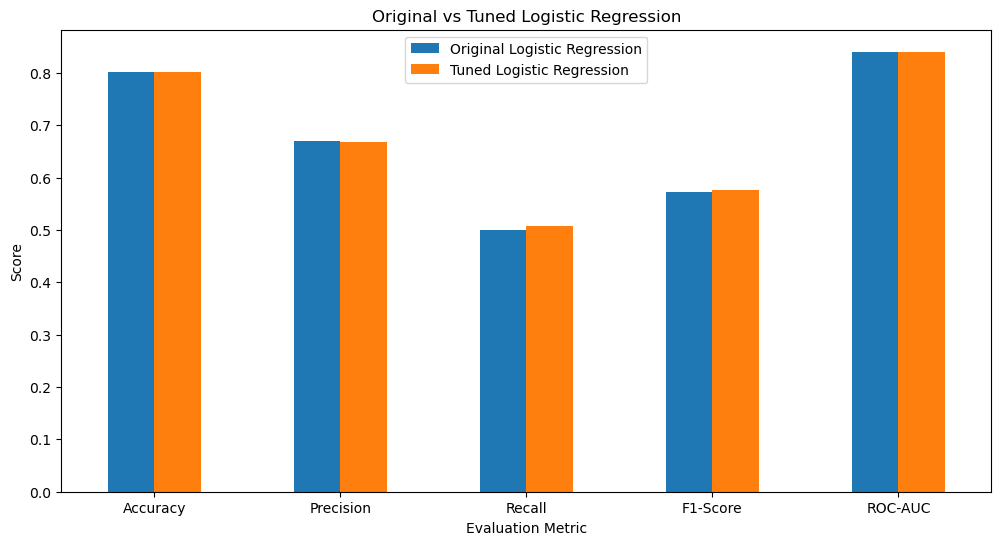

In [118]:
# Set the Metric column as the index for plotting
comparison_plot_tuned = logistic_tuning_comparison.set_index("Metric")

# Create a bar chart comparing original and tuned models
comparison_plot_tuned.plot(
    kind="bar",
    figsize=(12, 6)
)

# Add chart title and axis labels
plt.title("Original vs Tuned Logistic Regression")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Display the legend
plt.legend()

# Display the chart
plt.show()

# Final tuned model summary

In [119]:
# Print a concise summary of the final tuned model performance
print("Final Tuned Logistic Regression Performance")
print("--------------------------------------------")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1-Score :", round(f1_tuned, 4))
print("ROC-AUC  :", round(roc_auc_tuned, 4))

# Display the best hyperparameters used by the final model
print("\nBest Hyperparameters:")
print(best_params_logistic)

Final Tuned Logistic Regression Performance
--------------------------------------------
Accuracy : 0.8028
Precision: 0.6678
Recall   : 0.5081
F1-Score : 0.5771
ROC-AUC  : 0.8405

Best Hyperparameters:
{'C': 10, 'solver': 'liblinear'}


# 14 — Feature Importance and Churn Drivers

# Feature coefficients

In [120]:
# Extract the coefficients learned by the tuned Logistic Regression model
# Each coefficient represents the relationship between a feature
# and the predicted probability of customer churn

logistic_coefficients = pd.Series(
    tuned_logistic_model.coef_[0],
    index=X_train.columns
)

# Sort coefficients from lowest to highest
# Negative values are associated with lower churn probability
# Positive values are associated with higher churn probability
logistic_coefficients_sorted = logistic_coefficients.sort_values()

# Display the 15 features with the strongest negative coefficients
print("Top 15 features associated with lower churn probability:")
print(logistic_coefficients_sorted.head(15))

# Display the 15 features with the strongest positive coefficients
print("\nTop 15 features associated with higher churn probability:")
print(logistic_coefficients_sorted.tail(15).sort_values(ascending=False))

Top 15 features associated with lower churn probability:
tenure                                 -1.451861
MonthlyCharges                         -1.044732
Contract_Two year                      -0.612727
Contract_One year                      -0.283696
AverageMonthlyRevenue                  -0.216723
TenureGroup_13-24 Months               -0.115471
StreamingTV_No internet service        -0.101106
TechSupport_No internet service        -0.101106
DeviceProtection_No internet service   -0.101106
OnlineBackup_No internet service       -0.101106
OnlineSecurity_No internet service     -0.101106
StreamingMovies_No internet service    -0.101106
InternetService_No                     -0.101106
Dependents_Yes                         -0.079430
OnlineSecurity_Yes                     -0.061822
dtype: float64

Top 15 features associated with higher churn probability:
InternetService_Fiber optic       0.913020
TotalCharges                      0.407120
TenureGroup_49-72 Months          0.309302
Strea

# Positive and negative features prepare

In [121]:
# Select the 10 features with the strongest negative coefficients
# These features are associated with lower predicted churn probability
top_negative_features = logistic_coefficients_sorted.head(10)

# Select the 10 features with the strongest positive coefficients
# These features are associated with higher predicted churn probability
top_positive_features = logistic_coefficients_sorted.tail(10)

# Combine both groups into one DataFrame
feature_effects = pd.concat([
    top_negative_features,
    top_positive_features
])

# Display the selected feature effects
feature_effects

tenure                                 -1.451861
MonthlyCharges                         -1.044732
Contract_Two year                      -0.612727
Contract_One year                      -0.283696
AverageMonthlyRevenue                  -0.216723
TenureGroup_13-24 Months               -0.115471
StreamingTV_No internet service        -0.101106
TechSupport_No internet service        -0.101106
DeviceProtection_No internet service   -0.101106
OnlineBackup_No internet service       -0.101106
DeviceProtection_Yes                    0.092744
SeniorCitizen                           0.095324
PaymentMethod_Electronic check          0.137464
PaperlessBilling_Yes                    0.167434
MultipleLines_Yes                       0.263503
StreamingTV_Yes                         0.293308
StreamingMovies_Yes                     0.305947
TenureGroup_49-72 Months                0.309302
TotalCharges                            0.407120
InternetService_Fiber optic             0.913020
dtype: float64

# Feature coefficient visualization

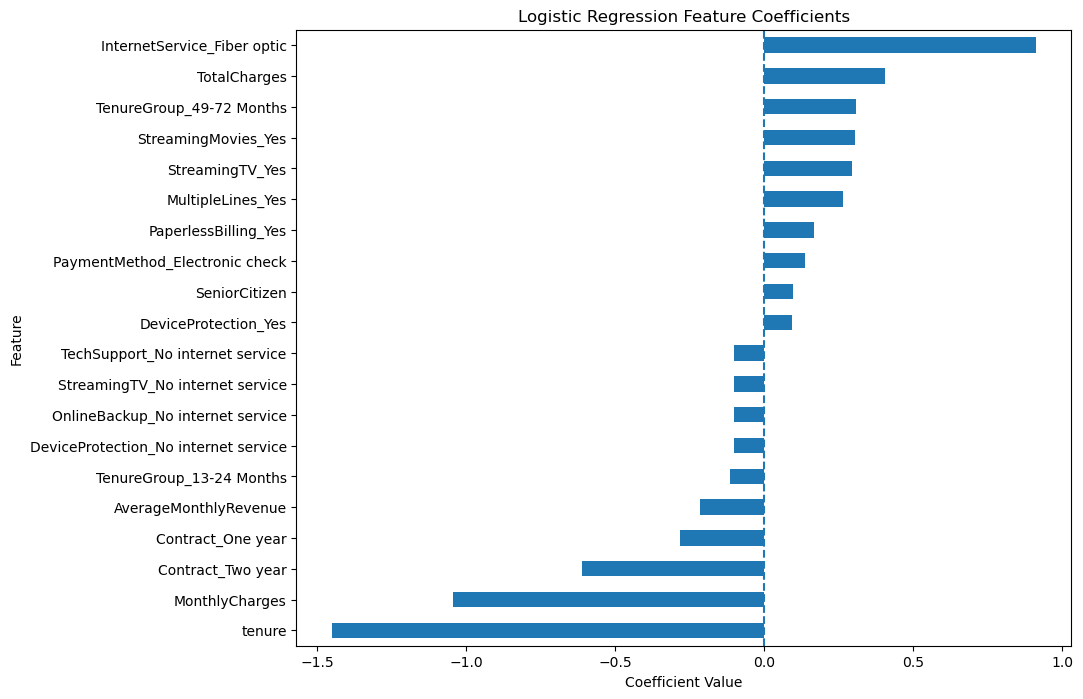

In [122]:
# Create a horizontal bar chart for the selected feature coefficients
plt.figure(figsize=(10, 8))

# Plot the coefficient values
feature_effects.sort_values().plot(kind="barh")

# Add chart title and axis labels
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

# Add a vertical reference line at zero
# Values on the left are negative and values on the right are positive
plt.axvline(x=0, linestyle="--")

# Display the chart
plt.show()

# Business interpretation table

In [123]:
# Create a table containing the strongest churn-related features
# This table will be useful for the final business recommendations

feature_interpretation = pd.DataFrame({
    "Feature": feature_effects.index,
    "Coefficient": feature_effects.values,
    "Direction": [
        "Lower predicted churn" if value < 0 else "Higher predicted churn"
        for value in feature_effects.values
    ]
})

# Round coefficient values for readability
feature_interpretation["Coefficient"] = (
    feature_interpretation["Coefficient"].round(4)
)

# Display the interpretation table
feature_interpretation

,Feature,Coefficient,Direction
0,tenure,-1.4519,Lower predicted churn
1,MonthlyCharges,-1.0447,Lower predicted churn
2,Contract_Two year,-0.6127,Lower predicted churn
3,Contract_One year,-0.2837,Lower predicted churn
4,AverageMonthlyRevenue,-0.2167,Lower predicted churn
5,TenureGroup_13-24 Months,-0.1155,Lower predicted churn
6,StreamingTV_No internet service,-0.1011,Lower predicted churn
7,TechSupport_No internet service,-0.1011,Lower predicted churn
8,DeviceProtection_No internet service,-0.1011,Lower predicted churn
9,OnlineBackup_No internet service,-0.1011,Lower predicted churn


# 15 — Customer Churn Risk Scoring

# Test customers  risk score

In [124]:
# Create a copy of the original test dataset
# This will allow us to attach churn predictions to customer information
risk_df = df_model.loc[X_test.index].copy()

# Add the actual churn status of each customer
risk_df["Actual_Churn"] = y_test.values

# Add the churn probability predicted by the tuned Logistic Regression model
risk_df["Churn_Probability"] = y_prob_tuned

# Convert churn probability into percentage format
risk_df["Churn_Probability_Percent"] = (
    risk_df["Churn_Probability"] * 100
).round(2)

# Display the first 10 customers with their churn probabilities
risk_df[
    ["Churn_Probability", "Churn_Probability_Percent", "Actual_Churn"]
].head(10)

,Churn_Probability,Churn_Probability_Percent,Actual_Churn
5615,0.786613,78.66,0
6112,0.544073,54.41,1
2356,0.293740,29.37,1
2196,0.043266,4.33,0
832,0.011047,1.10,0
683,0.298194,29.82,0
3395,0.163306,16.33,0
6226,0.837952,83.80,1
3987,0.011212,1.12,0
4275,0.012527,1.25,0


# Risk categories

In [125]:
# Create customer risk categories based on predicted churn probability
# High Risk: probability >= 70%
# Medium Risk: probability between 40% and 70%
# Low Risk: probability < 40%

risk_df["Risk_Category"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Display the number of customers in each risk category
print("Customer Risk Category Distribution:")
print(risk_df["Risk_Category"].value_counts())

Customer Risk Category Distribution:
Risk_Category
Low Risk       1015
Medium Risk     294
High Risk        96
Name: count, dtype: int64


# High-risk customers

In [126]:
# Filter customers classified as High Risk
# These customers have a predicted churn probability of 70% or higher
high_risk_customers = risk_df[
    risk_df["Risk_Category"] == "High Risk"
].copy()

# Sort high-risk customers from highest to lowest churn probability
high_risk_customers = high_risk_customers.sort_values(
    by="Churn_Probability",
    ascending=False
)

# Display the top 20 highest-risk customers
high_risk_customers.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AverageMonthlyRevenue,Actual_Churn,Churn_Probability,Churn_Probability_Percent,Risk_Category
6353,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Electronic check,94.00,181.70,1,0-12 Months,90.850000,1,0.882465,88.25,High Risk
3741,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Electronic check,93.85,196.75,1,0-12 Months,98.375000,1,0.880509,88.05,High Risk
2203,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Electronic check,100.80,100.80,1,0-12 Months,100.800000,1,0.879224,87.92,High Risk
5975,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,No,...,Electronic check,94.60,279.55,1,0-12 Months,93.183333,1,0.876942,87.69,High Risk
2739,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Electronic check,86.05,86.05,1,0-12 Months,86.050000,1,0.850966,85.10,High Risk
6201,Female,1,No,No,6,Yes,Yes,Fiber optic,No,Yes,...,Electronic check,98.25,560.60,1,0-12 Months,93.433333,1,0.849484,84.95,High Risk
935,Female,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Electronic check,83.25,308.05,0,0-12 Months,77.012500,0,0.847564,84.76,High Risk
1147,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,Electronic check,95.15,196.90,1,0-12 Months,98.450000,1,0.842292,84.23,High Risk
582,Female,1,No,No,4,Yes,Yes,Fiber optic,No,No,...,Electronic check,89.20,346.20,1,0-12 Months,86.550000,1,0.840049,84.00,High Risk
6226,Male,0,No,Yes,1,Yes,Yes,Fiber optic,No,No,...,Electronic check,93.30,93.30,1,0-12 Months,93.300000,1,0.837952,83.80,High Risk


# Risk distribution visualization

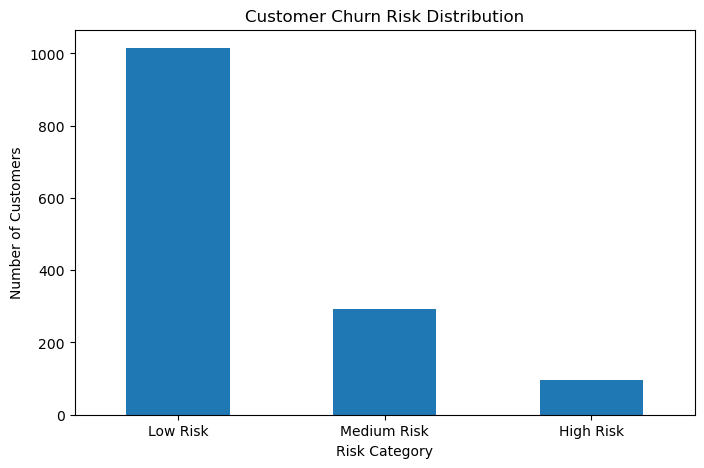

In [127]:
# Count customers in each risk category
risk_counts = risk_df["Risk_Category"].value_counts().reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

# Create a bar chart showing customer risk distribution
plt.figure(figsize=(8, 5))

# Plot the risk category counts
risk_counts.plot(kind="bar")

# Add chart title and labels
plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

# Save high-risk customer list

In [128]:
# Save the high-risk customer list as a CSV file
# This file can later be used by the business/retention team
# to identify customers who may need targeted retention actions

high_risk_customers.to_csv(
    "../data/high_risk_customers.csv",
    index=False
)

# Display confirmation
print("High-risk customer list saved successfully!")
print("Number of high-risk customers:", len(high_risk_customers))

High-risk customer list saved successfully!
Number of high-risk customers: 96


# 16 — Customer Retention Strategy

# Retention action rules

In [129]:
# Create a function to recommend a retention action
# based on the customer's characteristics and predicted churn risk

def recommend_retention_action(row):
    """
    Generate a simple retention recommendation
    based on customer contract, internet service,
    payment method and churn probability.
    """

    # High-risk customers on month-to-month contracts
    # may benefit from a contract-related retention offer
    if row["Churn_Probability"] >= 0.70 and row["Contract"] == "Month-to-month":
        return "Offer a long-term contract incentive"

    # Customers without online security may benefit
    # from a security-related service offer
    elif row["OnlineSecurity"] == "No":
        return "Offer Online Security service"

    # Customers without technical support may benefit
    # from technical assistance or support offers
    elif row["TechSupport"] == "No":
        return "Offer Technical Support service"

    # Customers using electronic check payment
    # can be encouraged toward alternative payment methods
    elif row["PaymentMethod"] == "Electronic check":
        return "Promote automatic payment options"

    # General retention action for other high-risk customers
    else:
        return "Offer personalized retention incentive"


# Apply the retention recommendation function
# to every customer in the risk dataset
risk_df["Recommended_Action"] = risk_df.apply(
    recommend_retention_action,
    axis=1
)

# Display sample customers with their recommended actions
risk_df[
    [
        "Churn_Probability_Percent",
        "Risk_Category",
        "Recommended_Action"
    ]
].head(10)

,Churn_Probability_Percent,Risk_Category,Recommended_Action
5615,78.66,High Risk,Offer a long-term contract incentive
6112,54.41,Medium Risk,Offer Online Security service
2356,29.37,Low Risk,Offer Online Security service
2196,4.33,Low Risk,Offer personalized retention incentive
832,1.10,Low Risk,Offer personalized retention incentive
683,29.82,Low Risk,Offer Online Security service
3395,16.33,Low Risk,Offer personalized retention incentive
6226,83.80,High Risk,Offer a long-term contract incentive
3987,1.12,Low Risk,Offer personalized retention incentive
4275,1.25,Low Risk,Offer personalized retention incentive


# High-risk retention list

In [130]:
# Create a final high-risk customer retention dataset
# containing customers who need potential retention attention

retention_df = risk_df[
    risk_df["Risk_Category"] == "High Risk"
].copy()

# Sort customers from highest to lowest churn probability
retention_df = retention_df.sort_values(
    by="Churn_Probability",
    ascending=False
)

# Display important columns for the retention team
retention_df[
    [
        "Churn_Probability_Percent",
        "Risk_Category",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "OnlineSecurity",
        "TechSupport",
        "Recommended_Action"
    ]
].head(20)

,Churn_Probability_Percent,Risk_Category,Contract,InternetService,PaymentMethod,OnlineSecurity,TechSupport,Recommended_Action
6353,88.25,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
3741,88.05,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
2203,87.92,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
5975,87.69,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
2739,85.10,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
6201,84.95,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
935,84.76,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
1147,84.23,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
582,84.00,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive
6226,83.80,High Risk,Month-to-month,Fiber optic,Electronic check,No,No,Offer a long-term contract incentive


# Recommended action distribution

In [131]:
# Count how many high-risk customers received each recommended action
action_counts = retention_df["Recommended_Action"].value_counts()

# Display the action distribution
print("Recommended Retention Actions:")
print(action_counts)

Recommended Retention Actions:
Recommended_Action
Offer a long-term contract incentive    96
Name: count, dtype: int64


# Retention action chart

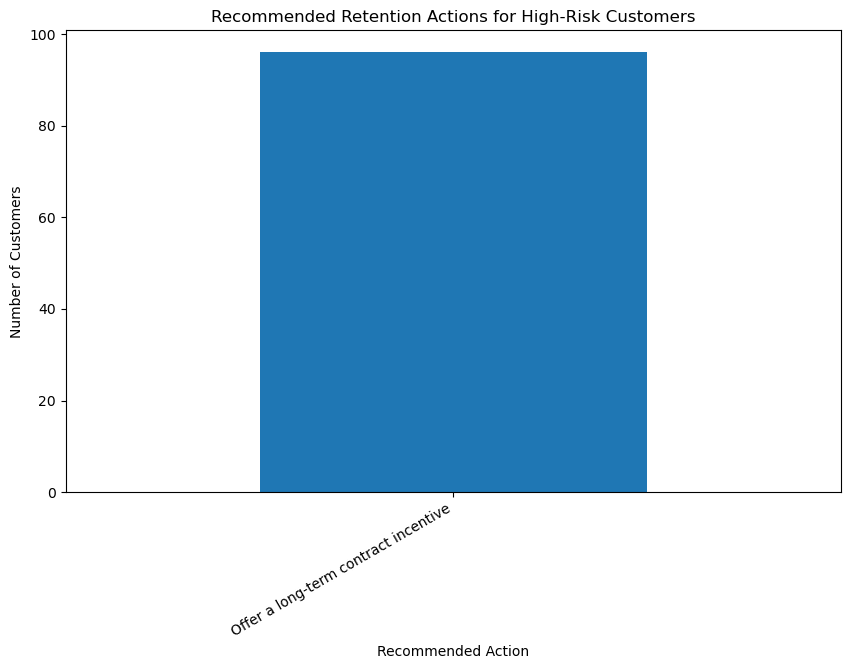

In [132]:
# Create a bar chart showing the number of high-risk customers
# associated with each recommended retention action

plt.figure(figsize=(10, 6))

# Plot retention action counts
action_counts.plot(kind="bar")

# Add chart title and labels
plt.title("Recommended Retention Actions for High-Risk Customers")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Customers")

# Rotate labels for better readability
plt.xticks(rotation=30, ha="right")

# Display the chart
plt.show()

# Save retention strategy file

In [133]:
# Save the high-risk customer retention strategy dataset
# This file can be used later in the dashboard or business report

retention_df.to_csv(
    "../data/customer_retention_strategy.csv",
    index=False
)

# Display confirmation
print("Customer retention strategy saved successfully!")
print("Number of high-risk customers:", len(retention_df))

Customer retention strategy saved successfully!
Number of high-risk customers: 96


# 17 — Final Churn Drivers Summary

# Top churn drivers

In [134]:
# Get the features with the strongest positive coefficients
# Positive coefficients are associated with higher predicted churn probability

top_churn_drivers = (
    logistic_coefficients
    .sort_values(ascending=False)
    .head(10)
)

# Convert the results into a DataFrame
top_churn_drivers_df = pd.DataFrame({
    "Feature": top_churn_drivers.index,
    "Coefficient": top_churn_drivers.values
})

# Round coefficient values for readability
top_churn_drivers_df["Coefficient"] = (
    top_churn_drivers_df["Coefficient"].round(4)
)

# Display the top churn-related features
top_churn_drivers_df

,Feature,Coefficient
0,InternetService_Fiber optic,0.9130
1,TotalCharges,0.4071
2,TenureGroup_49-72 Months,0.3093
3,StreamingMovies_Yes,0.3059
4,StreamingTV_Yes,0.2933
5,MultipleLines_Yes,0.2635
6,PaperlessBilling_Yes,0.1674
7,PaymentMethod_Electronic check,0.1375
8,SeniorCitizen,0.0953
9,DeviceProtection_Yes,0.0927


# Top retention-related features

In [135]:
# Get the features with the strongest negative coefficients
# Negative coefficients are associated with lower predicted churn probability

top_retention_features = (
    logistic_coefficients
    .sort_values(ascending=True)
    .head(10)
)

# Convert the results into a DataFrame
top_retention_features_df = pd.DataFrame({
    "Feature": top_retention_features.index,
    "Coefficient": top_retention_features.values
})

# Round coefficient values
top_retention_features_df["Coefficient"] = (
    top_retention_features_df["Coefficient"].round(4)
)

# Display the features associated with lower predicted churn
top_retention_features_df

,Feature,Coefficient
0,tenure,-1.4519
1,MonthlyCharges,-1.0447
2,Contract_Two year,-0.6127
3,Contract_One year,-0.2837
4,AverageMonthlyRevenue,-0.2167
5,TenureGroup_13-24 Months,-0.1155
6,StreamingTV_No internet service,-0.1011
7,TechSupport_No internet service,-0.1011
8,DeviceProtection_No internet service,-0.1011
9,OnlineBackup_No internet service,-0.1011


# Visualize top churn drivers

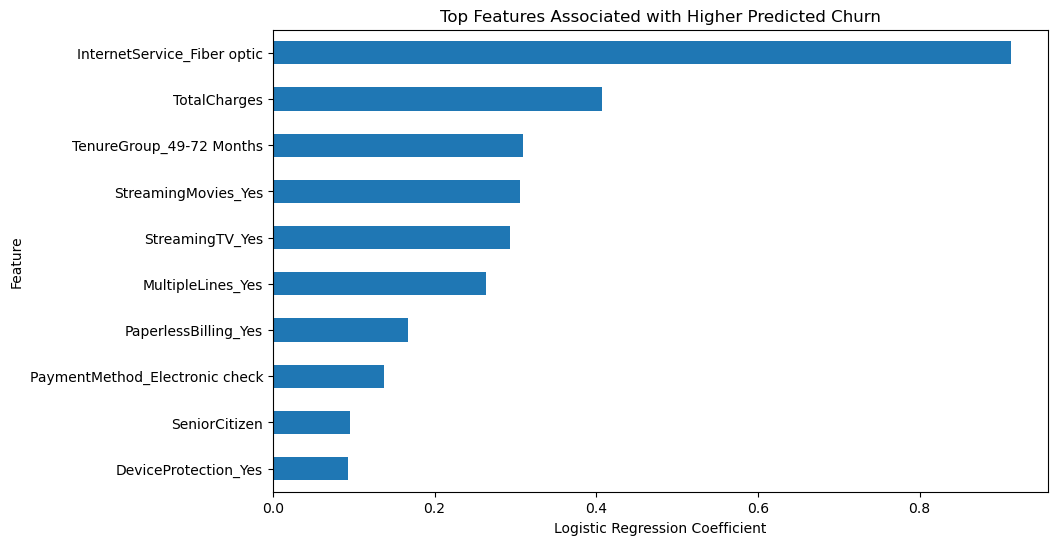

In [136]:
# Create a horizontal bar chart for the strongest positive churn-related features
plt.figure(figsize=(10, 6))

# Plot the top churn drivers
top_churn_drivers.sort_values().plot(kind="barh")

# Add chart title and axis labels
plt.title("Top Features Associated with Higher Predicted Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

# Display the chart
plt.show()

# Final business summary

In [137]:
# Display a concise summary of the final project results
print("FINAL CUSTOMER CHURN PROJECT SUMMARY")
print("====================================")
print()

# Display the final model information
print("Final Model: Tuned Logistic Regression")
print("Best Parameters:", best_params_logistic)
print()

# Display final model performance
print("Model Performance:")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1-Score :", round(f1_tuned, 4))
print("ROC-AUC  :", round(roc_auc_tuned, 4))
print()

# Display the number of high-risk customers identified
print("High-Risk Customers Identified:",
      len(high_risk_customers))

# Display the number of retention recommendations generated
print("Retention Recommendations Generated:",
      len(retention_df))

FINAL CUSTOMER CHURN PROJECT SUMMARY

Final Model: Tuned Logistic Regression
Best Parameters: {'C': 10, 'solver': 'liblinear'}

Model Performance:
Accuracy : 0.8028
Precision: 0.6678
Recall   : 0.5081
F1-Score : 0.5771
ROC-AUC  : 0.8405

High-Risk Customers Identified: 96
Retention Recommendations Generated: 96


# Save model-ready feature list

In [138]:
# Save the final feature names used by the machine learning model
# This will be important when we build the Streamlit application
# because new customer input must follow the same feature structure

feature_names = X_train.columns.tolist()

# Save the feature names as a text file
with open("../models/feature_names.txt", "w") as file:
    for feature in feature_names:
        file.write(feature + "\n")

# Display confirmation
print("Model feature names saved successfully!")
print("Total model features:", len(feature_names))

Model feature names saved successfully!
Total model features: 34


# 18 — Save Final Model + Scaler

# Import joblib

In [139]:
# Import joblib for saving and loading machine learning models
# Joblib is commonly used to serialize Scikit-learn models
import joblib

# Display confirmation message
print("Joblib imported successfully!")

Joblib imported successfully!


# Save tuned Logistic Regression model

In [141]:
# Save the final tuned Logistic Regression model
# This model will later be used by the Streamlit application
joblib.dump(
    tuned_logistic_model,
    "../models/churn_model.pkl"
)

# Display confirmation
print("Final churn model saved successfully!")

Final churn model saved successfully!


# Save scaler

In [142]:
# Save the StandardScaler used during model training
# The same scaler must be applied to new customer data
# before making predictions

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

# Display confirmation
print("Scaler saved successfully!")

Scaler saved successfully!


# Verify saved files

In [143]:
# Load the saved churn model from the models folder
loaded_model = joblib.load(
    "../models/churn_model.pkl"
)

# Load the saved scaler
loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

# Display confirmation messages
print("Saved model loaded successfully!")
print("Saved scaler loaded successfully!")

# Display the loaded model
print("\nLoaded Model:")
print(loaded_model)

Saved model loaded successfully!
Saved scaler loaded successfully!

Loaded Model:
LogisticRegression(C=10, max_iter=1000, random_state=42, solver='liblinear')


# Verify model prediction

In [144]:
# Use the loaded model to make predictions on the test dataset
# This confirms that the saved model works correctly

loaded_predictions = loaded_model.predict(
    X_test_scaled
)

# Calculate accuracy using the loaded model
loaded_model_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

# Display the verification result
print(
    "Accuracy of loaded model:",
    round(loaded_model_accuracy, 4)
)

# Verify that the loaded model produces the same predictions
# as the original tuned model
print(
    "Predictions match original model:",
    np.array_equal(
        loaded_predictions,
        y_pred_tuned
    )
)

Accuracy of loaded model: 0.8028
Predictions match original model: True
